# Laboratorio 6 — Evaluación de Modelos de Clasificación
**Curso:** Minería de Datos (EIN132A25)

## Objetivos
- Interpretar la **matriz de confusión**
- Calcular **Precision, Recall y F1-score**
- Construir y analizar la **curva ROC** y el **AUC**
- Aplicar **validación cruzada**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

# Preparar dataset Titanic
filename = "titanic.csv"
if os.path.exists(filename):
    df = pd.read_csv(filename)
else:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.to_csv("titanic.csv", index=False)

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
embarked_dummies = pd.get_dummies(df["Embarked"], prefix="Embarked", drop_first=True)
df = pd.concat([df, embarked_dummies], axis=1)

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_Q", "Embarked_S"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print("Modelo entrenado.")

Modelo entrenado.


## 1. Matriz de confusión

Matriz de confusión:
[[103   7]
 [ 31  38]]


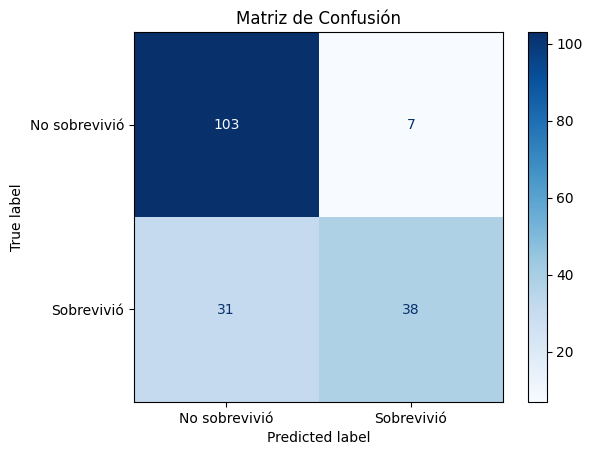

In [4]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

## 2. Precision, Recall y F1-score

In [5]:
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

               precision    recall  f1-score   support

No sobrevivió       0.77      0.94      0.84       110
   Sobrevivió       0.84      0.55      0.67        69

     accuracy                           0.79       179
    macro avg       0.81      0.74      0.76       179
 weighted avg       0.80      0.79      0.78       179



## 3. Curva ROC y AUC

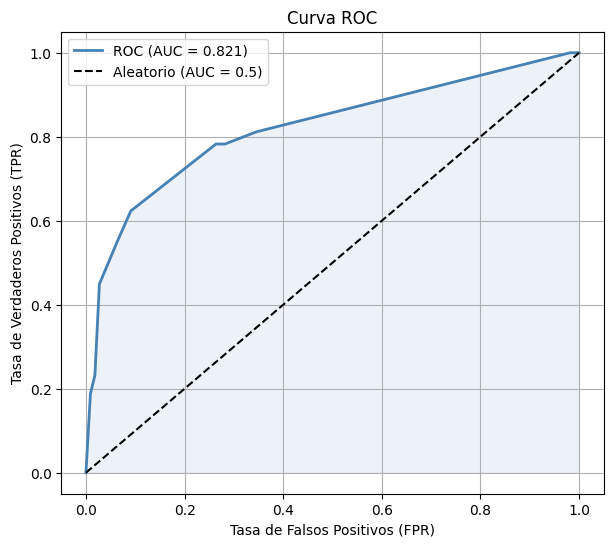

AUC: 0.8210


In [6]:
y_prob = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Aleatorio (AUC = 0.5)")
plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()
print(f"AUC: {auc:.4f}")

## 4. Validación cruzada

In [7]:
scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
print(f"Scores por fold: {scores}")
print(f"Media: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

Scores por fold: [0.75418994 0.8258427  0.80898876 0.78651685 0.84269663]
Media: 0.8036
Desviación estándar: 0.0309


In [8]:
resultados = cross_validate(modelo, X, y, cv=5,
    scoring=["accuracy", "precision", "recall", "f1"])
for metrica, valores in resultados.items():
    if metrica.startswith("test_"):
        print(f"{metrica[5:]:10s}: {valores.mean():.4f} ± {valores.std():.4f}")

accuracy  : 0.8036 ± 0.0309
precision : 0.8241 ± 0.0413
recall    : 0.6260 ± 0.1083
f1        : 0.7047 ± 0.0689


## Ejercicios

### Ejercicio 1 — Comparar max_depth=1 vs max_depth=10

In [9]:
from sklearn.metrics import accuracy_score, f1_score

for depth in [1, 10]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    yprob = m.predict_proba(X_test)[:, 1]
    print(f"\nmax_depth={depth}:")
    print(f"  Accuracy:  {accuracy_score(y_test, yp):.4f}")
    print(f"  F1-Score:  {f1_score(y_test, yp):.4f}")
    print(f"  AUC:       {roc_auc_score(y_test, yprob):.4f}")


max_depth=1:
  Accuracy:  0.7765
  F1-Score:  0.6923
  AUC:       0.7534

max_depth=10:
  Accuracy:  0.7989
  F1-Score:  0.7273
  AUC:       0.7615


### Ejercicio 2 — Efecto del umbral de decisión

In [10]:
for umbral in [0.3, 0.5, 0.7]:
    y_pred_nuevo = (y_prob >= umbral).astype(int)
    cm_u = confusion_matrix(y_test, y_pred_nuevo)
    print(f"\nUmbral {umbral}:")
    print(cm_u)


Umbral 0.3:
[[79 31]
 [15 54]]

Umbral 0.5:
[[100  10]
 [ 26  43]]

Umbral 0.7:
[[103   7]
 [ 31  38]]


### Desafío — Función evaluar_modelo

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "auc":       roc_auc_score(y_test, y_prob),
    }

resultado = evaluar_modelo(modelo, X_test, y_test)
for k, v in resultado.items():
    print(f"{k:10s}: {v:.4f}")

accuracy  : 0.7877
precision : 0.8444
recall    : 0.5507
f1        : 0.6667
auc       : 0.8210
